In [ ]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Shared "paper" look used across the benchmarking notebooks (whitegrid + colorblind
# palette + despined axes). Keep these in sync with the other plots/ notebooks so every
# figure in the paper renders consistently.
sns.set_theme(style="whitegrid", context="paper")

# rc overrides applied inside `with sns.plotting_context("paper", rc=PAPER_RC):` per cell.
PAPER_RC = {
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}

# Map each variant to a fixed colorblind-palette colour so the same variant keeps the
# same colour across every figure. Falls back to the palette by index for unknown names.
_palette = sns.color_palette("colorblind")
color_price_first = _palette[0]  # blue
color_bid_first = _palette[1]    # orange
color_adaptive = _palette[2]     # green
color_prometheus = _palette[3]   # red

color_map = {
    "price_first": color_price_first,
    "bid_first": color_bid_first,
    "adaptive": color_adaptive,
    "prometheus": color_prometheus,
}
fallback_palette = sns.color_palette("colorblind")


def color_for(name, i=0):
    """Stable colour for a variant name (fixed map, else palette by index)."""
    return color_map.get(name, fallback_palette[i % len(fallback_palette)])


# Solid line for the in-engine variants; the Prometheus (SOTA) baseline is drawn dashed +
# square markers so it stays distinguishable from the engine variants even in grayscale
# prints (matches the engine-vs-Prometheus convention in AddStatisticQueriesOverTime.ipynb).
style_map = {"prometheus": ("--", "s")}


def style_for(name):
    """(linestyle, marker) for a variant: dashed+square for the Prometheus baseline, solid otherwise."""
    return style_map.get(name, ("-", None))


def style_time_axis(ax):
    """Apply the shared paper styling to a throughput-over-time axis."""
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Throughput [MTup/s]")
    ax.grid(True, axis="both", linestyle=":", linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)


output_dir = "."

# CSV files the plotting cells expect to find inside `comparison_dir`.
# These are produced by run_adaptive_optimization_benchmark.sh (one per variant).
EXPECTED_CSVS = ["adaptive.csv", "prometheus.csv", "bid_first.csv", "price_first.csv"]

# Only plot the steady-state window [WINDOW_START_S, WINDOW_END_S] (seconds),
# dropping the warm-up before WINDOW_START_S and the tail after WINDOW_END_S.
# timestamp_ms is already relative to run start (see write_throughput_csv).
WINDOW_START_S = 5
WINDOW_END_S = 200

# Average throughput into fixed time bins of this width (ms) before plotting.
BIN_MS = 1000

# Draw a marker only every Nth binned point so the Prometheus square markers stay legible
# instead of fusing into a solid band over the (cropped, binned) time series.
MARKEVERY = 12


def crop_to_window(df, start_s=WINDOW_START_S, end_s=WINDOW_END_S):
    """Keep rows in [start_s, end_s] seconds and normalize so time starts at 0."""
    start_ms, end_ms = start_s * 1000, end_s * 1000
    df = df[(df["timestamp_ms"] >= start_ms) & (df["timestamp_ms"] <= end_ms)].copy()
    df["timestamp_ms"] = df["timestamp_ms"] - start_ms
    return df


def average_per_bin(df, bin_ms=BIN_MS):
    """Average throughput within fixed `bin_ms` time bins; index each point at its bin start."""
    df = df.copy()
    df["timestamp_ms"] = (df["timestamp_ms"] // bin_ms) * bin_ms
    return df.groupby("timestamp_ms", as_index=False)["throughput_tup_per_s"].mean()


def load_data_only(path):
    df = pd.read_csv(path)
    if "query_type" in df.columns:
        df = df[df["query_type"] == "data"]
    return average_per_bin(crop_to_window(df))


def warn_missing_csvs(comparison_dir, expected=EXPECTED_CSVS):
    """Print a warning for any missing CSV (don't raise) and return those present.

    Lets the plotting cells render whatever variants exist while still flagging
    which expected file(s) are absent and how to produce them.
    """
    if os.path.isdir(comparison_dir):
        missing = [n for n in expected if not os.path.isfile(os.path.join(comparison_dir, n))]
    else:
        missing = list(expected)
    if missing:
        listing = "\n".join(f"  - {n}" for n in missing)
        print(
            f"WARNING: missing throughput CSV(s) in '{os.path.abspath(comparison_dir)}':\n"
            f"{listing}\n"
            "These variants will be skipped. To produce them, run the benchmark wrapper:\n"
            "  scripts/benchmarking/adaptive-optimization/run_adaptive_optimization_benchmark.sh \\\n"
            f"      --results-dir {comparison_dir}\n"
        )
    return [n for n in expected if n not in missing]

In [ ]:
import glob

comparison_dir = "."
# Warn about any missing variant (e.g. adaptive.csv) but plot whatever exists.
warn_missing_csvs(comparison_dir)

csv_paths = sorted(
    glob.glob(os.path.join(comparison_dir, "*.csv")),
    key=lambda p: ("adaptive" in os.path.basename(p), os.path.basename(p)),
)

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    for i, path in enumerate(csv_paths):
        name = os.path.splitext(os.path.basename(path))[0]
        df = load_data_only(path)
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            df["throughput_tup_per_s"] / 1e6,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=name.replace("_", " "),
        )

    ax.set_title("Throughput Over Time (adaptive comparison)")
    style_time_axis(ax)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/throughput_over_time_adaptive_comparison.pdf", dpi=300, bbox_inches="tight")
    plt.show()

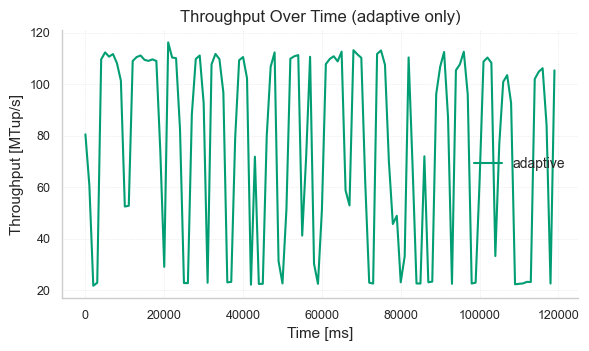

In [3]:
if not warn_missing_csvs(comparison_dir, expected=["adaptive.csv"]):
    print("Skipping adaptive-only plot.")
else:
    adaptive_path = os.path.join(comparison_dir, "adaptive.csv")
    df_adaptive_only = load_data_only(adaptive_path)

    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(6.0, 3.6))
        ax.plot(
            df_adaptive_only["timestamp_ms"],
            df_adaptive_only["throughput_tup_per_s"] / 1e6,
            color=color_adaptive,
            linewidth=1.5,
            label="adaptive",
        )

        ax.set_title("Throughput Over Time (adaptive only)")
        style_time_axis(ax)
        ax.legend(frameon=False)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/throughput_over_time_adaptive_only.pdf", dpi=300, bbox_inches="tight")
        plt.show()

In [ ]:
import glob

# Pick the single maximum throughput value across all variants, then plot (max - value)
# over time for each variant: the gap from the global peak throughput. The variant that
# achieves the peak touches 0 there; larger values are further below the best observed.
warn_missing_csvs(comparison_dir)

csv_paths = sorted(
    glob.glob(os.path.join(comparison_dir, "*.csv")),
    key=lambda p: ("adaptive" in os.path.basename(p), os.path.basename(p)),
)
dfs = {os.path.splitext(os.path.basename(p))[0]: load_data_only(p) for p in csv_paths}

# The single maximum throughput value over every variant and timestamp.
#global_max = max(df["throughput_tup_per_s"].max() for df in dfs.values())
global_min = min(df["throughput_tup_per_s"].min() for df in dfs.values())

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    for i, (name, df) in enumerate(dfs.items()):
        # Gap from the peak; clamp negatives (throughput above global_max) to 0.
        gap = (df["throughput_tup_per_s"] - global_min) / 1e6
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            gap,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=name.replace("_", " "),
        )

    ax.set_title("Throughput gap from global peak (over time)")
    style_time_axis(ax)
    ax.set_ylabel("Max − Throughput [MTup/s]")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/throughput_over_time_gap_from_max.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
import glob

# Same as the comparison plot, but each variant is drawn in its own separate figure.
warn_missing_csvs(comparison_dir)

csv_paths = sorted(
    glob.glob(os.path.join(comparison_dir, "*.csv")),
    key=lambda p: ("adaptive" in os.path.basename(p), os.path.basename(p)),
)
for i, path in enumerate(csv_paths):
    name = os.path.splitext(os.path.basename(path))[0]
    df = load_data_only(path)

    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(6.0, 3.6))
        ls, marker = style_for(name)
        ax.plot(
            df["timestamp_ms"],
            df["throughput_tup_per_s"] / 1e6,
            color=color_for(name, i),
            linestyle=ls,
            marker=marker,
            markersize=4,
            markevery=MARKEVERY,
            linewidth=1.5,
            label=name.replace("_", " "),
        )

        ax.set_title(f"Throughput Over Time ({name.replace('_', ' ')})")
        style_time_axis(ax)
        ax.legend(frameon=False)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/throughput_over_time_{name}.pdf", dpi=300, bbox_inches="tight")
        plt.show()

In [ ]:
import glob

# Bar plot of each variant's average throughput over the whole (cropped, binned) run.
warn_missing_csvs(comparison_dir)

csv_paths = sorted(
    glob.glob(os.path.join(comparison_dir, "*.csv")),
    key=lambda p: ("adaptive" in os.path.basename(p), os.path.basename(p)),
)
names, means, colors, hatches = [], [], [], []
for i, path in enumerate(csv_paths):
    name = os.path.splitext(os.path.basename(path))[0]
    df = load_data_only(path)
    names.append(name.replace("_", " "))
    means.append(df["throughput_tup_per_s"].mean() / 1e6)
    colors.append(color_for(name, i))
    # Hatch the Prometheus (SOTA) bar so it stays distinguishable in grayscale prints,
    # matching the dashed/square treatment of its line in the time-series plots.
    hatches.append("//" if name == "prometheus" else "")

with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(6.0, 3.6))
    bars = ax.bar(names, means, color=colors, width=0.6)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    ax.bar_label(bars, fmt="%.1f", padding=3)

    ax.set_ylabel("Avg throughput [MTup/s]")
    ax.set_title("Average Throughput per Variant")
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/average_throughput_bar.pdf", dpi=300, bbox_inches="tight")
    plt.show()